In [1]:
import tensorflow as tf 
from tensorflow.keras.datasets import mnist
import numpy as np 
import matplotlib.pyplot as plt
import random

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

The image wee see is 1


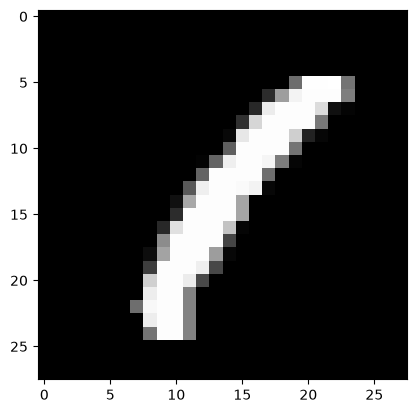

In [4]:
idx = random.randint(0,X_train.shape[0]-1)
img2show, label = X_train[idx],y_train[idx]
print(f'The image wee see is {label}')
plt.imshow(img2show, cmap='gray')

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_train[idx]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 109, 254, 254, 255, 116,   0,   0,
          0,   0],
       [  

In [7]:
X_train, X_test = X_train.reshape(-1, 28*28), X_test.reshape(-1, 28*28)
y_train, y_test=tf.keras.utils.to_categorical(y_train, 10), tf.keras.utils.to_categorical(y_test, 10)
X_train, X_test = X_train/255.0, X_test/255.0

In [8]:
X_train[idx]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [9]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam

In [10]:
X_train[idx].shape

(784,)

In [11]:
model = Sequential()
model.add(Dense(784, activation='relu', input_shape = (784,)))
model.add(Dense(36, activation = 'relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

C:\Users\youss\miniconda3-pbe\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 784)                 │         615,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 36)                  │          28,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             370 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 644,070 (2.46 MB)

 Trainable params: 644,070 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
model.fit(X_train, y_train, epochs=10, batch_size=36, validation_data=(X_test, y_test))

Epoch 1/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8503 - loss: 0.5745 - val_accuracy: 0.9159 - val_loss: 0.2935
Epoch 2/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9240 - loss: 0.2693 - val_accuracy: 0.9335 - val_loss: 0.2342
Epoch 3/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9381 - loss: 0.2191 - val_accuracy: 0.9432 - val_loss: 0.1955
Epoch 4/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9469 - loss: 0.1873 - val_accuracy: 0.9487 - val_loss: 0.1729
Epoch 5/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9537 - loss: 0.1634 - val_accuracy: 0.9553 - val_loss: 0.1535
Epoch 6/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9593 - loss: 0.1449 - val_accuracy: 0.9583 - val_loss: 0.1413
Epoch 7/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9636 - loss: 0.1295 - val_accuracy: 0.9620 - val_loss: 0.1290
Epoch 8/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9676 - loss: 0.1168 - 

In [18]:
idx_test = random.randint(0, X_test.shape[0]-1)
img_test = X_test[idx_test]
img_test = np.expand_dims(img_test, axis=0)
prediction = model.predict(img_test) 
predict_label = np.argmax(prediction)
true_label = y_test[idx_test]
print(f'The predicted label is {predict_label} and the true label is {np.argmax(true_label)}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
The predicted label is 6 and the true label is 6


In [17]:
img_test.shape

(1, 784)

In [19]:
prediction


array([[2.0157750e-05, 2.8011959e-08, 1.2642530e-03, 5.1384479e-08,
        4.2780139e-04, 8.8255456e-06, 9.9825460e-01, 1.8595618e-05,
        8.4442217e-07, 4.9079003e-06]], dtype=float32)

In [20]:
true_label

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])